# Assignment 1
## SVM Regression for Concrete Strength Prediction

This project follows the **Machine Learning (ML) checklist** to build a Support Vector Machine (SVM) regression model for predicting concrete strength.

### **1. Frame the Problem**
- The goal is to predict **concrete strength** based on material composition and curing time.
- This is a **supervised regression problem**.
- Performance metrics used: **MSE, RMSE, and R² score**.

### **2. Get the Data**
- Dataset includes:
  - Features: `Cement`, `Blast Furnace Slag`, `Water`, `Superplasticizer`, `Coarse Aggregate`, `Fine Aggregate`, `Age`
  - Target: `Strength`
- Data is loaded from `your_dataset.csv`.

In [28]:
import pandas as pd

df = pd.read_csv("dataset/concrete_data.csv")

### **3. Explore the Data**
- Statistical overview (`df.describe()`)
- Check for missing values (`df.isnull().sum()`).
- Visualize distributions and correlations (`df.corr()`).

In [56]:
df.describe()
df.isnull().sum()
df.corr()
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


### **4. Prepare the Data**
- Handle missing values if any.
- Standardize numerical features using `StandardScaler()`.
- Split data into training and testing sets (80/20 split).


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['Cement', 'Blast Furnace Slag', 'Water', 'Superplasticizer', 
        'Coarse Aggregate', 'Fine Aggregate', 'Age']]
y = df['Strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64


### **5. Shortlist Promising Models**
- We compare **SVM Regression** with other models like **Linear Regression**.
- Initial SVM training with default hyperparameters.


In [31]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)

### **6. Fine-Tune the System**
- Use **GridSearchCV** to find the best hyperparameters for `C`, `gamma`, and `epsilon`.


In [38]:

param_grid = {
    'kernel': ['rbf', 'poly', 'linear', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5],
}
grid_search = RandomizedSearchCV(SVR(), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")



Best parameters: {'kernel': 'rbf', 'gamma': 0.1, 'epsilon': 0.5, 'C': 10}


### **7. Present the Solution**
- Compare models and visualize actual vs. predicted values.
- Compute final performance metrics.

Mean Squared Error (MSE): 46.72
Root Mean Squared Error (RMSE): 6.84
R² Score: 0.8187


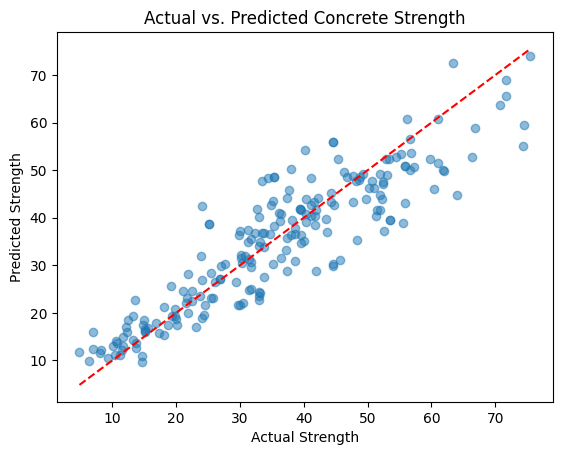

[4.83, 75.5] [4.83, 75.5]


31     52.91
109    55.90
136    74.50
88     35.30
918    10.54
       ...  
482    56.14
545    18.75
110    38.00
514    74.36
602    35.17
Name: Strength, Length: 206, dtype: float64

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs. Predicted Concrete Strength")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()
print([min(y_test), max(y_test)], [min(y_test), max(y_test)])
y_test

### **8. Deploy & Monitor**
- Save the trained model and scaler for future use.
- Load and test on new data.

In [34]:
# import joblib

# joblib.dump(best_svr, "svr_model.pkl")
# joblib.dump(scaler, "scaler.pkl")

# loaded_model = joblib.load("svr_model.pkl")
# loaded_scaler = joblib.load("scaler.pkl")

# new_data = np.array([[300, 100, 180, 10, 980, 770, 28]])
# new_data_scaled = loaded_scaler.transform(new_data)
# prediction = loaded_model.predict(new_data_scaled)

# print(f"Predicted Concrete Strength: {prediction}")